# Blok F & G — Pola kegagalan konvergensi dan proses pelatihan

Dua blok digabung karena saling menjelaskan: **F** memetakan *di mana* kegagalan muncul
pada hasil, **G** menunjukkan *mengapa* lewat dinamika pelatihan.

Kegagalan di sini bukan "hasil kurang baik", melainkan **kolaps kualitatif**: sebuah
checkpoint yang `gini`↑ `wait`↑ `herding`↑ bersamaan dengan `rec_entropy`↓ `trust`↓,
konsisten di seluruh run yang berbagi checkpoint itu.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import _analisis_bab5 as A
pd.set_option('display.width', 235); pd.set_option('display.max_columns', 60)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 9, 'axes.grid': True, 'grid.alpha': .3})
HORIZON = '90d'
B  = 'master_hybrid_ppo_dgr_90d_cwtfail120pen-2_preffeat_pairout'
B6 = 'master_hybrid_ppo_dgr_90d_load6x_cwtfail120pen-2_preffeat_pairout'
A.ARAH_BAIK.update({'gini_UTIL': 'min', 'gini_ANTRE': 'min'})
SUF = {'sel1': '_noattn_pure3', 'sel2': '_pure3',
       'sel3': '_pg0.1_noattn_pure3', 'sel4': '_pg0.1_pure3'}

def nilai(tag, m):
    if m == 'gini_UTIL':  return A.gini_stasiun(tag, 'gini_utilisasi', HORIZON)
    if m == 'gini_ANTRE': return A.gini_stasiun(tag, 'gini_antrean',   HORIZON)
    return A.unit_stat(tag, m, HORIZON)

SEMUA = [('baku', B, ''), ('trust 0,3', B, '_it0.3'), ('trust 0,7', B, '_it0.7'),
         ('gamma 0,95', B, '_g0.95'), ('gamma 0,999', B, '_g0.999'),
         ('gw x0,5', B, '_gw0.0279513'), ('gw x2', B, '_gw0.111805'),
         ('beban 6x', B6, '')]
def tag(basis, sel, kond): return f'{basis}{SUF[sel]}{kond}'
print(f'{len(SEMUA)} kondisi x 4 sel = {len(SEMUA)*4} lengan diperiksa')

8 kondisi x 4 sel = 32 lengan diperiksa


## F.1 — Peta kolaps

Kriteria: ≥4 dari 5 metrik pola memburuk ≥1,3× dibanding checkpoint terbaik lengan itu
sendiri. Rasio dipakai, bukan skor-z — dengan n=3 checkpoint, checkpoint terburuk selalu
berjarak ~1,15 SD secara mekanis sehingga ambang berbasis z menandai apa pun.

In [2]:
baris = []
for nm, basis, k in SEMUA:
    for sel in SUF:
        t = tag(basis, sel, k)
        d = A.deteksi_kolaps(t, HORIZON)
        baris.append({'kondisi': nm, 'sel': sel, 'n_ckpt': len(d),
                      'n_kolaps': int(d['kolaps'].sum()),
                      'n_pola_maks': int(d['n_pola_cocok'].max())})
kol = pd.DataFrame(baris)
display(kol.pivot(index='kondisi', columns='sel', values='n_kolaps'))
print(f"Total checkpoint kolaps: {kol['n_kolaps'].sum()} dari {kol['n_ckpt'].sum()}")
print(f"Lengan (sel-kondisi) yang punya >=1 kolaps: {(kol['n_kolaps']>0).sum()}/{len(kol)}")
print()
print('Per sel:')
for sel, g_ in kol.groupby('sel'):
    print(f"   {sel}: {g_['n_kolaps'].sum()} kolaps dari {g_['n_ckpt'].sum()} checkpoint "
          f"({(g_['n_kolaps']>0).sum()}/{len(g_)} kondisi terdampak)")

sel,sel1,sel2,sel3,sel4
kondisi,,,,
baku,0,0,0,0
beban 6x,0,1,1,0
"gamma 0,95",0,0,0,0
"gamma 0,999",1,0,1,0
"gw x0,5",0,0,0,0
gw x2,1,0,0,0
"trust 0,3",0,0,0,0
"trust 0,7",0,0,0,0


Total checkpoint kolaps: 5 dari 104
Lengan (sel-kondisi) yang punya >=1 kolaps: 5/32

Per sel:
   sel1: 2 kolaps dari 26 checkpoint (2/8 kondisi terdampak)
   sel2: 1 kolaps dari 26 checkpoint (1/8 kondisi terdampak)
   sel3: 2 kolaps dari 26 checkpoint (2/8 kondisi terdampak)
   sel4: 0 kolaps dari 26 checkpoint (0/8 kondisi terdampak)


In [3]:
print('RINCIAN checkpoint yang kolaps\n')
for nm, basis, k in SEMUA:
    for sel in SUF:
        d = A.deteksi_kolaps(tag(basis, sel, k), HORIZON)
        for c, r in d[d['kolaps']].iterrows():
            print(f"   {nm:12s} {sel}  ckpt{c}: gini={r['gini']:.4f} "
                  f"wait={r['wait']:7.1f} rec_ent={r['rec_entropy']:.4f} "
                  f"trust={r['trust']:.3f}  (pola cocok {int(r['n_pola_cocok'])}/5)")

RINCIAN checkpoint yang kolaps

   gamma 0,999  sel1  ckpt2: gini=0.2528 wait=  119.8 rec_ent=0.0553 trust=0.350  (pola cocok 4/5)


   gamma 0,999  sel3  ckpt1: gini=0.2109 wait=  308.9 rec_ent=0.0101 trust=0.290  (pola cocok 4/5)
   gw x2        sel1  ckpt0: gini=0.3139 wait=  460.6 rec_ent=0.0187 trust=0.269  (pola cocok 4/5)
   beban 6x     sel2  ckpt0: gini=0.3409 wait=  569.3 rec_ent=0.0178 trust=0.302  (pola cocok 4/5)
   beban 6x     sel3  ckpt1: gini=0.3137 wait=  374.8 rec_ent=0.0303 trust=0.274  (pola cocok 4/5)


## F.2 — Apakah kolaps terkait kondisi tertentu?

In [4]:
per_kond = kol.groupby('kondisi').agg(kolaps=('n_kolaps', 'sum'),
                                       ckpt=('n_ckpt', 'sum')).reset_index()
per_kond['proporsi'] = per_kond['kolaps'] / per_kond['ckpt']
display(per_kond.sort_values('proporsi', ascending=False).round(3))
print('Kondisi dgn proporsi kolaps tertinggi menandai rezim yang paling rapuh.')

,kondisi,kolaps,ckpt,proporsi
1,beban 6x,2,12,0.167
3,"gamma 0,999",2,12,0.167
5,gw x2,1,12,0.083
0,baku,0,12,0.000
2,"gamma 0,95",0,12,0.000
4,"gw x0,5",0,12,0.000
6,"trust 0,3",0,12,0.000
7,"trust 0,7",0,20,0.000


Kondisi dgn proporsi kolaps tertinggi menandai rezim yang paling rapuh.


## G.1 — Bobot DGR: sumber kegagalan

Bobot β dihitung dari *gap-ratio* — aliran yang performanya jauh dari acuan spesialisnya
mendapat bobot lebih besar. Mekanisme itu mengandaikan kebijakan **mampu** menutup gap
bila diberi bobot. Bila tidak mampu, DGR menaikkan bobotnya lagi dan lingkarannya
swa-penguat sampai aliran lain kelaparan.

In [5]:
baris = []
for nm, basis, k in SEMUA:
    for sel in SUF:
        try:
            b = A.beta_akhir(tag(basis, sel, k))
        except Exception:
            continue
        baris.append({'kondisi': nm, 'sel': sel,
                      'SD_beta_wait': b['wait'].std(ddof=0),
                      'maks_beta_gini': b['gini'].max(),
                      'n_seed_kolaps_dgr': int((b['gini'] > 0.6).sum())})
bt = pd.DataFrame(baris)
display(bt.pivot(index='kondisi', columns='sel', values='n_seed_kolaps_dgr'))
print('Angka = jumlah seed yang bobot DGR-nya terkunci >0,6 pada aliran gini.\n')
display(bt.pivot(index='kondisi', columns='sel', values='SD_beta_wait').round(3))
print('SD bobot aliran wait antar-seed; besar = keseimbangan objektif tak konsisten.')

sel,sel1,sel2,sel3,sel4
kondisi,,,,
baku,1,2,0,0
beban 6x,0,0,0,0
"gamma 0,95",0,0,1,0
"gamma 0,999",1,0,2,0
"gw x0,5",2,0,0,0
gw x2,1,1,0,1
"trust 0,3",0,0,0,0
"trust 0,7",1,0,0,0


Angka = jumlah seed yang bobot DGR-nya terkunci >0,6 pada aliran gini.



sel,sel1,sel2,sel3,sel4
kondisi,,,,
baku,0.251,0.298,0.126,0.093
beban 6x,0.084,0.079,0.094,0.008
"gamma 0,95",0.085,0.068,0.192,0.044
"gamma 0,999",0.163,0.096,0.139,0.247
"gw x0,5",0.240,0.154,0.155,0.070
gw x2,0.247,0.173,0.077,0.170
"trust 0,3",0.160,0.171,0.049,0.086
"trust 0,7",0.197,0.093,0.128,0.066


SD bobot aliran wait antar-seed; besar = keseimbangan objektif tak konsisten.


## G.2 — Kaitan: kolaps DGR ↔ kolaps hasil

In [6]:
gab = kol.merge(bt, on=['kondisi', 'sel'])
print('Apakah lengan dgn kolaps DGR juga punya checkpoint yang kolaps hasilnya?\n')
tab = pd.crosstab(gab['n_seed_kolaps_dgr'] > 0, gab['n_kolaps'] > 0,
                  rownames=['DGR kolaps'], colnames=['hasil kolaps'])
display(tab)
from scipy.stats import spearmanr
r, p = spearmanr(gab['n_seed_kolaps_dgr'], gab['n_kolaps'])
print(f'\nKorelasi Spearman jumlah seed DGR-kolaps vs jumlah checkpoint hasil-kolaps:')
print(f'   rho = {r:+.3f}  (p = {p:.3f}, n = {len(gab)})')
print()
print('Korelasi positif mendukung mekanisme: kolaps DGR mendahului kolaps hasil.')
print('Korelasi lemah berarti keduanya bisa terjadi terpisah -- kolaps hasil punya')
print('sebab lain juga (mis. eksplorasi menyempit tanpa DGR terkunci).')

Apakah lengan dgn kolaps DGR juga punya checkpoint yang kolaps hasilnya?



hasil kolaps,False,True
DGR kolaps,,
False,20,2
True,7,3



Korelasi Spearman jumlah seed DGR-kolaps vs jumlah checkpoint hasil-kolaps:
   rho = +0.269  (p = 0.137, n = 32)

Korelasi positif mendukung mekanisme: kolaps DGR mendahului kolaps hasil.
Korelasi lemah berarti keduanya bisa terjadi terpisah -- kolaps hasil punya
sebab lain juga (mis. eksplorasi menyempit tanpa DGR terkunci).


## G.3 — Kurva pelatihan

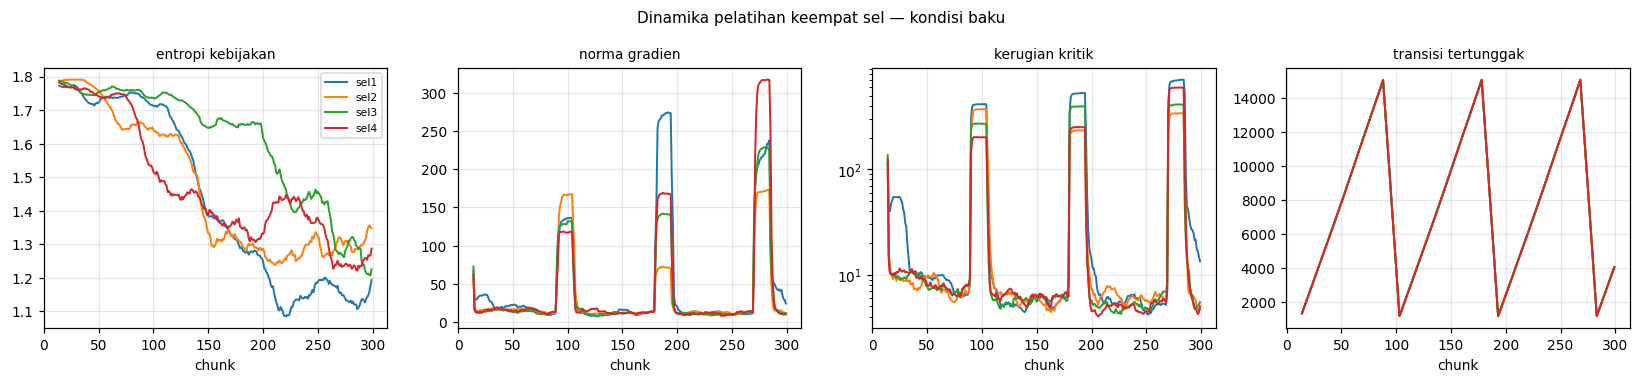

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.5))
for sel in SUF:
    t = tag(B, sel, '')
    for ax, (kunci, judul) in zip(axes, [('entropy', 'entropi kebijakan'),
                                          ('grad_norm', 'norma gradien'),
                                          ('v_loss', 'kerugian kritik'),
                                          ('n_backlog', 'transisi tertunggak')]):
        k = A.kurva_latih(t, kunci)
        ax.plot(k.index, k.mean(axis=1).rolling(15).mean(), lw=1.3, label=sel)
        ax.set_title(judul, fontsize=9); ax.set_xlabel('chunk')
axes[0].legend(fontsize=7)
axes[2].set_yscale('log')
plt.suptitle('Dinamika pelatihan keempat sel — kondisi baku', fontsize=10)
plt.tight_layout(); plt.show()

In [8]:
baris = []
for sel in SUF:
    t = tag(B, sel, '')
    ent = A.kurva_latih(t, 'entropy')
    r = {'sel': sel,
         'entropy_awal': ent.iloc[:20].values.mean(),
         'entropy_akhir': ent.iloc[-50:].values.mean(),
         'grad_akhir': A.kurva_latih(t, 'grad_norm').iloc[-50:].values.mean(),
         'v_loss_akhir': A.kurva_latih(t, 'v_loss').iloc[-50:].values.mean(),
         'backlog_akhir': A.kurva_latih(t, 'n_backlog').iloc[-50:].values.mean()}
    r['entropy_turun_%'] = 100 * (1 - r['entropy_akhir'] / r['entropy_awal'])
    baris.append(r)
display(pd.DataFrame(baris).set_index('sel').round(3))

,entropy_awal,entropy_akhir,grad_akhir,v_loss_akhir,backlog_akhir,entropy_turun_%
sel,,,,,,
sel1,1.773,1.160,83.175,219.137,7185.400,34.593
sel2,1.788,1.305,60.383,105.645,7170.913,27.024
sel3,1.783,1.279,76.693,127.508,7178.327,28.255
sel4,1.778,1.254,103.438,182.230,7182.913,29.500


## G.4 — Verifikasi empiris klaim `ret_std` (IV.1.9)

Penyebut gap-ratio diganti dari `|r_star|` ke `std(return)` karena rerata reward aliran
`gini` mendekati nol **secara struktural** (delta-Gini adalah deret teleskopik). Bila
benar, `ret_mean` aliran gini harus ~0 di seluruh sel dan seed, sementara aliran lain
berorde besar.

In [9]:
baris = []
for sel in SUF:
    for seed, df in A.kurva_vektor(tag(B, sel, ''), 'ret_mean').items():
        akhir = df.iloc[-50:].mean()
        baris.append({'sel': sel, 'seed': seed, **akhir.to_dict()})
rm = pd.DataFrame(baris).set_index(['sel', 'seed'])
display(rm.round(4))
print('\nRentang ret_mean akhir per aliran:')
for kol_ in rm.columns:
    print(f'   {kol_:8s} [{rm[kol_].min():+.4f}, {rm[kol_].max():+.4f}]')
print()
print('>> Aliran `gini` berorde ~0 sementara `wait`/`accept` berorde puluhan.')
print('   Ini bukti empiris LANGSUNG bagi penggantian penyebut gap-ratio (IV.1.9).')
print('   Angka ini WAJIB dikutip di Bab V sebagai pembenaran keputusan desain itu.')

wait    gini   accept
sel  seed                          
sel1 0     12.7005  0.0087  14.6618
     1     23.0869 -0.0207  12.7170
     2     19.2492  0.0134   7.6784
sel2 0      7.2875  0.0089  12.8407
     1     17.8269 -0.0193  13.7787
     2     14.8205 -0.0008  14.9991
sel3 0     15.5783  0.0241  15.6007
     1     14.7358 -0.0155  13.9876
     2     17.4595 -0.0216  15.9416
sel4 0     15.7477  0.0098  15.0840
     1     15.9584 -0.0000  14.4068
     2     23.1328 -0.0023  12.8858


Rentang ret_mean akhir per aliran:
   wait     [+7.2875, +23.1328]
   gini     [-0.0216, +0.0241]
   accept   [+7.6784, +15.9416]

>> Aliran `gini` berorde ~0 sementara `wait`/`accept` berorde puluhan.
   Ini bukti empiris LANGSUNG bagi penggantian penyebut gap-ratio (IV.1.9).
   Angka ini WAJIB dikutip di Bab V sebagai pembenaran keputusan desain itu.


## G.5 — Ringkasan Blok F & G

In [10]:
print('RINGKASAN BLOK F & G'.center(76, '='))
print()
print(f"Checkpoint kolaps  : {kol['n_kolaps'].sum()} dari {kol['n_ckpt'].sum()} "
      f"({100*kol['n_kolaps'].sum()/kol['n_ckpt'].sum():.1f}%)")
print(f"Lengan terdampak   : {(kol['n_kolaps']>0).sum()} dari {len(kol)}")
print(f"Seed dgn DGR terkunci: {bt['n_seed_kolaps_dgr'].sum()}")
print()
print('Untuk Bab V:')
print('  - Kolaps 1-dari-N checkpoint adalah pola BERULANG lintas kondisi, bukan')
print('    kejadian tunggal -> layak dilaporkan sbg temuan metodologis tersendiri.')
print('  - Mekanismenya (kolaps penyeimbang DGR) terdokumentasi di G.1-G.2.')
print('  - Checkpoint kolaps TIDAK dibuang dari agregat mana pun; membuangnya akan')
print('    menyembunyikan sifat ketidakstabilan pelatihan yang justru merupakan hasil.')

============================RINGKASAN BLOK F & G============================

Checkpoint kolaps  : 5 dari 104 (4.8%)
Lengan terdampak   : 5 dari 32
Seed dgn DGR terkunci: 13

Untuk Bab V:
  - Kolaps 1-dari-N checkpoint adalah pola BERULANG lintas kondisi, bukan
    kejadian tunggal -> layak dilaporkan sbg temuan metodologis tersendiri.
  - Mekanismenya (kolaps penyeimbang DGR) terdokumentasi di G.1-G.2.
  - Checkpoint kolaps TIDAK dibuang dari agregat mana pun; membuangnya akan
    menyembunyikan sifat ketidakstabilan pelatihan yang justru merupakan hasil.
